# Zadanie 5: programowanie genetyczne i regresja symboliczna

### Autorzy: Anna Moroń, Kalina Rączka, Emilia Sarna

Termin realizacji: 18 maja 2026

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Zmodyfikuj przykład `pysr_demo.ipynb` tak, aby uczył się funkcji $f(x) = 2.2\sin(x_0 + 2 x_1) - x_5^2 - 3$ której dziedziną jest $\mathbb{R}^6$. Uczenie ma się odbywać w oparciu o 200 wylosowanych z dziedziny próbek (między -5 a 5).
2. Zanotuj wzory trzech rozwiązań o najwyższej wartości `score` oraz rozwiązanie `best` dla następujących zestawów ustawień:
   1. `binary_operators=["+", "*"], unary_operators=["cos", "exp", "sin"], maxsize=20`,
   2. `binary_operators=["+", "*", "-", "^"], unary_operators=["cos", "exp", "sin", "log"], maxsize=30`, (dodaj ograniczenie dla argumentów operatora "^": [https://astroautomata.com/PySR/v1.5.9/options.html#constraining-use-of-operators](https://astroautomata.com/PySR/v1.5.9/options.html#constraining-use-of-operators).
   3. `binary_operators=["+", "*", "-", "^"], unary_operators=["exp", "sin"], maxsize=15`.
3. Powtórz eksperymenty z zadania na 3.0 po dodaniu szumu do próbek z funkcji $f$ (rozkład normalny o średniej 0 i odchyleniu standardowym 0.5)

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Dodaj do porównania dopasowanie oparte o próbki losowane w szerszym zakresie (między -15 a 15) oraz wyższy poziom szumu (odchylenie standardowe równe 2 oraz 5).

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Zamień funkcję $f$ na $f(x) = 2.2\sin(x_0 + 2x_1) - x_5^2 - p(\lfloor x_0 \rfloor)$ gdzie $p(i)$ oznacza $i$-tą liczbę pierwszą. Uwzględnij `p` jako dodatkowy operator unarny analogicznie do przykładu "Julia packages and types" z notatnika `pysr_demo.ipynb`. Powtórz eksperymenty opisane w zadaniach na 3.0 i 4.0.


In [1]:
import pysr
import sympy
import numpy as np
from matplotlib import pyplot as plt
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split

[juliapkg] Found dependencies: /home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/juliacall/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] Installing Julia 1.11.9 using JuliaUp
[juliapkg] Using Julia 1.11.9 at /home/mist/.julia/juliaup/julia-1.11.9+0.x64.linux.gnu/bin/julia
[juliapkg] Using Julia project at /home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/julia_env
[juliapkg] Writing Project.toml:
           | [deps]
           | SymbolicRegression = "8254be44-1295-4e6a-a16d-46603ac705cb"
           | Serialization = "9e88b42a-f829-5b0c-bbe9-9e923198166b"
           | PythonCall = "6099a3de-0909-46bc

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed pixi_jll ───────────────── v0.41.3+0
   Installed ScientificTypesBase ────── v3.1.0
   Installed MicroMamba ─────────────── v0.1.15
   Installed Tricks ─────────────────── v0.1.13
   Installed MLJModelInterface ──────── v1.11.1
   Installed DynamicExpressions ─────── v1.10.4
   Installed JSON ───────────────────── v1.5.2
   Installed PythonCall ─────────────── v0.9.26
   Installed StatisticalTraits ──────── v3.5.0
   Installed Pidfile ────────────────── v1.3.0
   Installed OpenSSL_jll ────────────── v3.0.20+0
   Installed micromamba_jll ─────────── v2.3.1+0
   Installed ProgressMeter ──────────── v1.10.2
   Installed PrecompileTools ────────── v1.2.1
   Installed Parsers ────────────────── v2.8.4
   Installed DynamicDiff ────────────── v0.2.1
   Installed TestItems ──────────────── v1.0.0
   Installed UnsafePointers ─────────── v1.0.0
   Installed Interfaces ─────────────── v0.3.2


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [17]:
import pandas as pd
from sklearn.metrics import r2_score

$f(x) = 2.2\sin(x_0 + 2 x_1) - x_5^2 - 3$ której dziedziną jest $\mathbb{R}^6$

In [28]:
# w oparciu o 200 wylosowanych z dziedziny próbek (między -5 a 5)
np.random.seed(0)
X = 5 * np.random.randn(200, 6)
y = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - 3

In [5]:
print(X)

[[  8.82026173   2.00078604   4.89368992  11.204466     9.33778995
   -4.8863894 ]
 [  4.75044209  -0.75678604  -0.51609426   2.05299251   0.72021786
    7.27136753]
 [  3.80518863   0.60837508   2.21931616   1.66837164   7.47039537
   -1.02579132]
 ...
 [ -1.50239393  -1.77514366  -9.46180947  -0.88906572   1.25499058
    5.27378963]
 [  4.80023871  -2.08249541  -1.38411497   5.61952653  -0.86731949
   -2.5501477 ]
 [  6.96259225   5.18792834   0.09395896  -2.96888724 -10.0594016
    2.94851803]]


In [18]:
default_pysr_params = dict(
    populations=30,
    model_selection="best",
    verbosity=0,
)

In [27]:
def run_all_setups(X, y):
    print("KONFIGURACJA 1")
    print("  binary_operators: ['+', '*']")
    print("  unary_operators: ['cos', 'exp', 'sin']")

    model1 = PySRRegressor(
        binary_operators=["+", "*"],
        unary_operators=["cos", "exp", "sin"],
        maxsize=20,
        **default_pysr_params,
    )
    model1.fit(X, y)

    print("\nTop 3 rozwiązania (maksymalny score):")
    eq1 = model1.equations_
    top3_eq1 = eq1.nlargest(3, 'score')[['complexity', 'loss', 'score', 'equation']]
    for idx, row in top3_eq1.iterrows():
        print(f"\n  [{row['complexity']}] Score: {row['score']:.6f}, Loss: {row['loss']:.6f}")
        print(f"  Równanie: {row['equation']}")

    print("\nBest solution (model_selection='best'):")
    best1 = model1.sympy()
    print(f"  {best1}")

    print("KONFIGURACJA 2")
    print("  binary_operators: ['+', '*', '-', '^']")
    print("  unary_operators: ['cos', 'exp', 'sin', 'log']")
    print("  constraints: '^' wymaga stałej jako drugiego argumentu")

    model2 = PySRRegressor(
        binary_operators=["+", "*", "-", "^"],
        unary_operators=["cos", "exp", "sin", "log"],
        maxsize=30,
        constraints={"^": (-1, 1)},
        **default_pysr_params,
    )
    model2.fit(X, y)

    print("\nTop 3 rozwiązania (maksymalny score):")
    eq2 = model2.equations_
    top3_eq2 = eq2.nlargest(3, 'score')[['complexity', 'loss', 'score', 'equation']]
    for idx, row in top3_eq2.iterrows():
        print(f"\n  [{row['complexity']}] Score: {row['score']:.6f}, Loss: {row['loss']:.6f}")
        print(f"  Równanie: {row['equation']}")

    print("\nBest solution (model_selection='best'):")
    best2 = model2.sympy()
    print(f"  {best2}")

    # Konfiguracja 3
    print("KONFIGURACJA 3")
    print("  binary_operators: ['+', '*', '-', '^']")
    print("  unary_operators: ['exp', 'sin']")

    model3 = PySRRegressor(
        binary_operators=["+", "*", "-", "^"],
        unary_operators=["exp", "sin"],
        maxsize=15,
        constraints={"^": (-1, 1)},
        **default_pysr_params,
    )
    model3.fit(X, y)

    print("\nTop 3 rozwiązania (maksymalny score):")
    eq3 = model3.equations_
    top3_eq3 = eq3.nlargest(3, 'score')[['complexity', 'loss', 'score', 'equation']]
    for idx, row in top3_eq3.iterrows():
        print(f"\n  [{row['complexity']}] Score: {row['score']:.6f}, Loss: {row['loss']:.6f}")
        print(f"  Równanie: {row['equation']}")

    print("\nBest solution (model_selection='best'):")
    best3 = model3.sympy()
    print(f"  {best3}")

    return model1, model2, model3

In [30]:
print("Wersja bez szumów")
model1, model2, model3 = run_all_setups(X, y)

Wersja bez szumów
KONFIGURACJA 1
  binary_operators: ['+', '*']
  unary_operators: ['cos', 'exp', 'sin']


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [5] Score: 4.491950, Loss: 8.701544
  Równanie: (x5 * -1.0570904) * x5

  [7] Score: 0.648067, Loss: 2.380635
  Równanie: ((x5 * -1.00369) * x5) + -3.1152098

  [18] Score: 0.055462, Loss: 2.010725
  Równanie: sin((x5 * 28.792038) + sin(exp(x2 + 0.38159326))) + (-3.139111 + (x5 * (x5 * -1.0021)))

Best solution (model_selection='best'):
  x5*(-1.00369)*x5 - 3.1152098
KONFIGURACJA 2
  binary_operators: ['+', '*', '-', '^']
  unary_operators: ['cos', 'exp', 'sin', 'log']
  constraints: '^' wymaga stałej jako drugiego argumentu


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [14] Score: 12.882952, Loss: 0.000000
  Równanie: ((sin(x0 + (x1 + x1)) * 2.2000003) + -3.0000005) - (x5 * x5)

  [5] Score: 5.783426, Loss: 2.391159
  Równanie: -3.1902835 - (x5 * x5)

  [12] Score: 1.107797, Loss: 0.711419
  Równanie: (sin((x0 + x1) + x1) + -3.1037855) - (x5 * x5)

Best solution (model_selection='best'):
  -x5*x5 + sin(x0 + x1 + x1)*2.2000003 - 3.0000005
KONFIGURACJA 3
  binary_operators: ['+', '*', '-', '^']
  unary_operators: ['exp', 'sin']


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [5] Score: 5.783166, Loss: 2.391159
  Równanie: -3.1902225 - (x5 * x5)

  [10] Score: 0.115278, Loss: 2.105012
  Równanie: (-3.2345028 + sin(21.059233 ^ x5)) - (x5 * x5)

  [13] Score: 0.004396, Loss: 2.077436
  Równanie: sin(sin(17.509909 ^ x5) * 2.621715) + (-3.198763 - (x5 * x5))

Best solution (model_selection='best'):
  -x5*x5 - 3.1902225


## Szumy

In [31]:
print(" EKSPERYMENTY Z SZUMEM N(0, 0.5)")

np.random.seed(0)
X_noisy = 5 * np.random.randn(200, 6)
noise = np.random.normal(0, 0.5, 200)
y_noisy = 2.2 * np.sin(X_noisy[:, 0] + 2 * X_noisy[:, 1]) - X_noisy[:, 5] ** 2 - 3 + noise

 EKSPERYMENTY Z SZUMEM N(0, 0.5)


In [32]:
model1_n, model2_n, model3_n = run_all_setups(X_noisy, y_noisy)

KONFIGURACJA 1
  binary_operators: ['+', '*']
  unary_operators: ['cos', 'exp', 'sin']


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [5] Score: 4.456694, Loss: 9.009994
  Równanie: x5 * (x5 * -1.056797)

  [19] Score: 1.054383, Loss: 0.334536
  Równanie: ((exp(0.6232986 + cos(((x1 + x1) + x0) + 1.585974)) + (x5 * x5)) * -0.9989775) + -0.6755918

  [16] Score: 0.725472, Loss: 0.960188
  Równanie: (cos(x0 + (x1 + (x1 + 1.5468683))) + ((x5 * x5) + 3.0490322)) * -1.002336

Best solution (model_selection='best'):
  (x5*x5 + exp(cos(x0 + x1 + x1 + 1.585974) + 0.6232986))*(-0.9989775) - 0.6755918
KONFIGURACJA 2
  binary_operators: ['+', '*', '-', '^']
  unary_operators: ['cos', 'exp', 'sin', 'log']
  constraints: '^' wymaga stałej jako drugiego argumentu


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [5] Score: 5.675520, Loss: 2.661484
  Równanie: -3.1898408 - (x5 * x5)

  [16] Score: 1.324993, Loss: 0.233463
  Równanie: (sin(x1 - ((-0.0019886782 - x1) - x0)) * 2.2170982) + (-2.998294 - (x5 * x5))

  [12] Score: 0.946775, Loss: 0.963219
  Równanie: (sin(x0 + (x1 * 2.0078638)) + -3.1051793) - (x5 * x5)

Best solution (model_selection='best'):
  -x5*x5 + sin(x1 - (-x0 - x1 - 0.0019886782))*2.2170982 - 2.998294
KONFIGURACJA 3
  binary_operators: ['+', '*', '-', '^']
  unary_operators: ['exp', 'sin']


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [5] Score: 5.675519, Loss: 2.661484
  Równanie: -3.1898403 - (x5 * x5)

  [11] Score: 0.022531, Loss: 2.473388
  Równanie: (-3.1825721 - (x5 * x5)) - sin(exp(x2 * 5.482674))

  [9] Score: 0.012584, Loss: 2.587396
  Równanie: -2.8300257 - (((x5 * x5) * 1.0822089) ^ 0.9838476)

Best solution (model_selection='best'):
  -x5*x5 - 3.1898403


In [33]:
results = []
for name, model, noisy in [
    ("Config 1", model1, False),
    ("Config 2", model2, False),
    ("Config 3", model3, False),
    ("Config 1", model1_n, True),
    ("Config 2", model2_n, True),
    ("Config 3", model3_n, True),
]:
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    best_eq = model.sympy()
    equations_df = model.equations_
    best_matches = equations_df[equations_df['equation'] == str(best_eq)]
    if best_matches.empty:
        best_row = equations_df.sort_values(['score', 'loss'], ascending=[False, True]).iloc[0]
    else:
        best_row = best_matches.iloc[0]

    results.append({
        "Konfiguracja": name,
        "Szum": "Tak" if noisy else "Nie",
        "Best Score": f"{best_row['score']:.6f}",
        "Best Loss": f"{best_row['loss']:.6f}",
        "R² (treningowy)": f"{r2:.6f}",
        "Złożoność": int(best_row['complexity']),
    })

results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))


Konfiguracja Szum Best Score Best Loss R² (treningowy)  Złożoność
    Config 1  Nie   4.491950  8.701544        0.996952          5
    Config 2  Nie  12.882952  0.000000        1.000000         14
    Config 3  Nie   5.783166  2.391159        0.996938          5
    Config 1  Tak   4.456694  9.009994        0.999819          5
    Config 2  Tak   5.675520  2.661484        1.000000          5
    Config 3  Tak   5.675519  2.661484        0.996938          5


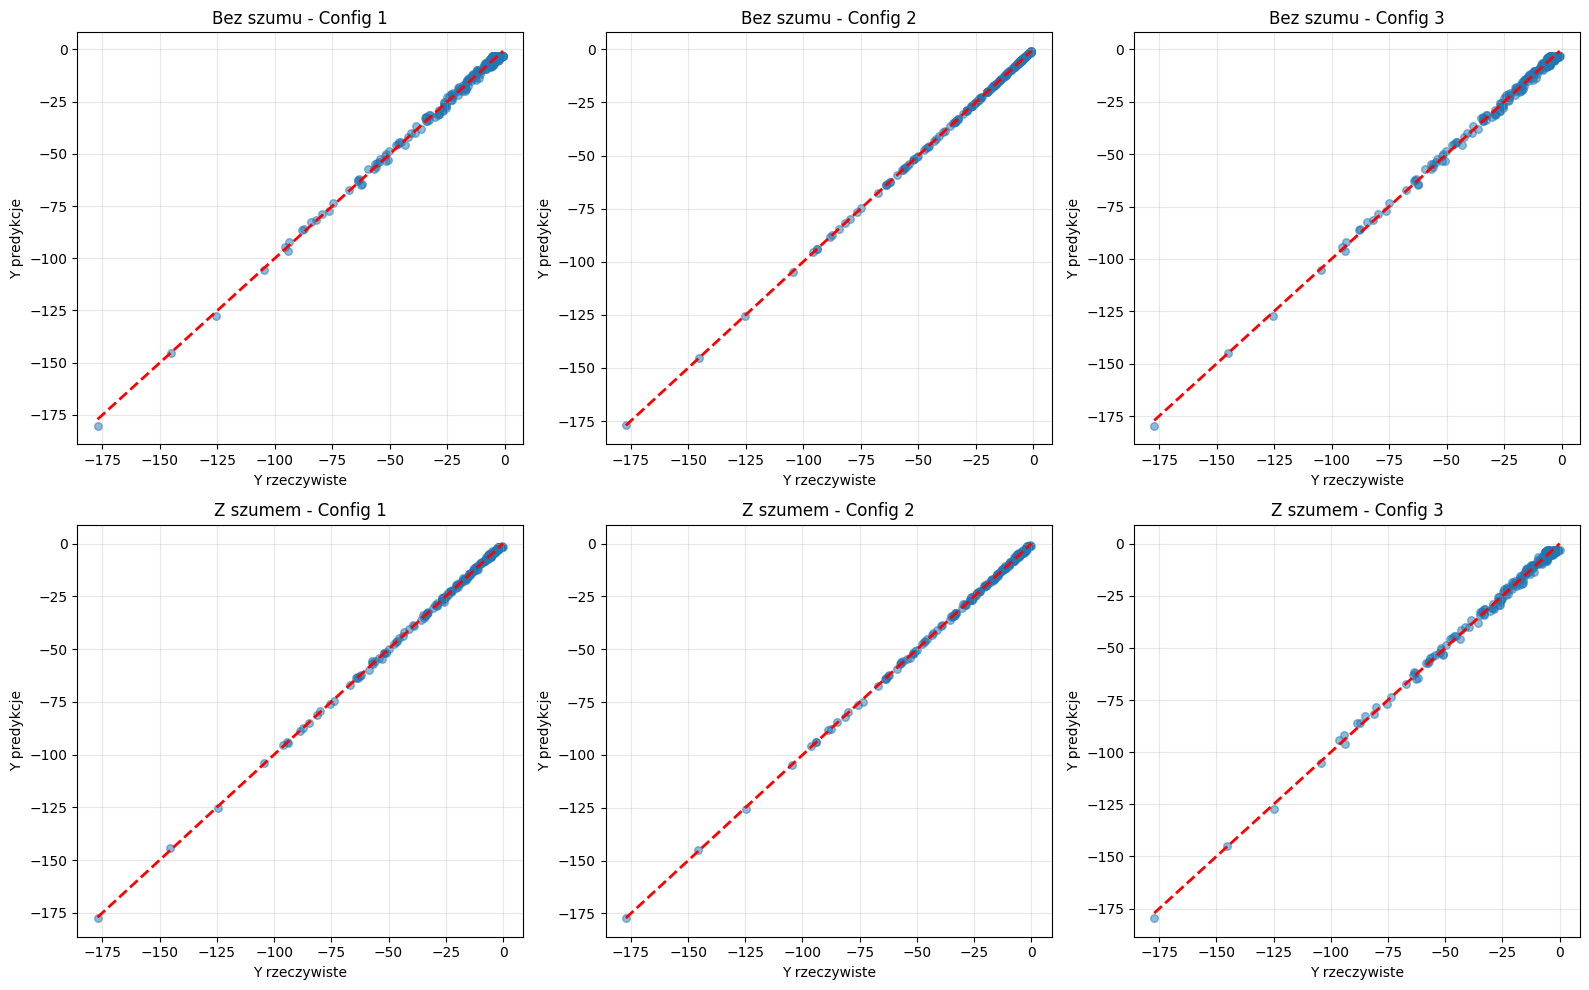

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

models_no_noise = [model1, model2, model3]
models_noise = [model1_n, model2_n, model3_n]
titles = ["Config 1", "Config 2", "Config 3"]

for idx, (model, ax, title) in enumerate(zip(models_no_noise, axes[0], titles)):
    y_pred = model.predict(X)
    ax.scatter(y, y_pred, alpha=0.5, s=30)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    ax.set_xlabel("Y rzeczywiste")
    ax.set_ylabel("Y predykcje")
    ax.set_title(f"Bez szumu - {title}")
    ax.grid(True, alpha=0.3)

for idx, (model, ax, title) in enumerate(zip(models_noise, axes[1], titles)):
    y_pred = model.predict(X_noisy)
    ax.scatter(y_noisy, y_pred, alpha=0.5, s=30)
    ax.plot([y_noisy.min(), y_noisy.max()], [y_noisy.min(), y_noisy.max()], 'r--', lw=2)
    ax.set_xlabel("Y rzeczywiste")
    ax.set_ylabel("Y predykcje")
    ax.set_title(f"Z szumem - {title}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Na 4.0

In [38]:
print(" EKSPERYMENTY Z SZUMEM N(0, 2)")

np.random.seed(0)
X15 = 15 * np.random.randn(200, 6)
y15_no_noise = 2.2 * np.sin(X15[:, 0] + 2 * X15[:, 1]) - X15[:, 5] ** 2 - 3

noise0_5 = np.random.normal(0, 0.5, 200)
y_noisy0_5 = y15_no_noise + noise0_5

noise2 = np.random.normal(0, 2, 200)
y_noisy2 = y15_no_noise + noise2

noise5 = np.random.normal(0, 5, 200)
y_noisy5 = y15_no_noise + noise5

 EKSPERYMENTY Z SZUMEM N(0, 2)


In [36]:
model15_1, model15_2, model15_3 = run_all_setups(X15, y15_no_noise)

KONFIGURACJA 1
  binary_operators: ['+', '*']
  unary_operators: ['cos', 'exp', 'sin']


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [16] Score: 21.123824, Loss: 0.000000
  Równanie: ((x5 * (x5 * -1.0)) + (sin((x1 + x1) + x0) * 2.2000036)) + -3.0000002

  [5] Score: 4.416381, Loss: 9.107293
  Równanie: x5 * (x5 * -1.0061811)

  [14] Score: 1.157373, Loss: 0.799311
  Równanie: (sin((x0 + x1) + x1) + (x5 * (x5 * -1.0001099))) + -3.0760026

Best solution (model_selection='best'):
  x5*x5*(-1.0) + sin(x0 + x1 + x1)*2.2000036 - 3.0000002
KONFIGURACJA 2
  binary_operators: ['+', '*', '-', '^']
  unary_operators: ['cos', 'exp', 'sin', 'log']
  constraints: '^' wymaga stałej jako drugiego argumentu


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [14] Score: 10.692026, Loss: 0.000000
  Równanie: (sin(x1 + (x0 + x1)) * 2.2000022) + (-3.0000021 - (x5 * x5))

  [5] Score: 5.024888, Loss: 2.689034
  Równanie: -3.1759644 - (x5 * x5)

  [12] Score: 1.152094, Loss: 0.800043
  Równanie: (sin((x0 + x1) + x1) - (x5 * x5)) + -3.095871

Best solution (model_selection='best'):
  -x5*x5 + sin(x0 + x1 + x1)*2.2000022 - 3.0000021
KONFIGURACJA 3
  binary_operators: ['+', '*', '-', '^']
  unary_operators: ['exp', 'sin']


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [5] Score: 5.024888, Loss: 2.689034
  Równanie: -3.1759644 - (x5 * x5)

  [10] Score: 0.044870, Loss: 2.540664
  Równanie: (sin(1.2601762 ^ x3) + -3.2884722) - (x5 * x5)

  [13] Score: 0.025998, Loss: 2.410223
  Równanie: (sin(exp(x5 * -1.1877078) + 0.56148577) + -3.4426522) - (x5 * x5)

Best solution (model_selection='best'):
  -x5*x5 - 3.1759644


In [37]:
model15_1_n0_5, model15_2_n0_5, model15_3_n0_5 = run_all_setups(X15, y_noisy0_5)

KONFIGURACJA 1
  binary_operators: ['+', '*']
  unary_operators: ['cos', 'exp', 'sin']


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [5] Score: 3.761354, Loss: 33.759090
  Równanie: (x5 * x5) * -1.0060545

  [7] Score: 0.108442, Loss: 27.176846
  Równanie: ((x5 * -0.9999971) * x5) + -3.179512

  [12] Score: 0.027993, Loss: 25.951370
  Równanie: (((x5 * -1.0001183) * x5) + -3.2640624) + sin(x5 * 13.568347)

Best solution (model_selection='best'):
  x5*x5*(-1.0060545)
KONFIGURACJA 2
  binary_operators: ['+', '*', '-', '^']
  unary_operators: ['cos', 'exp', 'sin', 'log']
  constraints: '^' wymaga stałej jako drugiego argumentu


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [5] Score: 3.868211, Loss: 27.176857
  Równanie: -3.1785405 - (x5 * x5)

  [10] Score: 0.023873, Loss: 26.105907
  Równanie: (sin(x2 * -0.63367313) - (x5 * x5)) + -3.161037

  [11] Score: 0.018657, Loss: 25.623363
  Równanie: cos(exp(x2 - -0.60379887)) - ((x5 * x5) + 3.5267723)

Best solution (model_selection='best'):
  -x5*x5 - 3.1785405
KONFIGURACJA 3
  binary_operators: ['+', '*', '-', '^']
  unary_operators: ['exp', 'sin']


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [5] Score: 3.868211, Loss: 27.176857
  Równanie: -3.1786637 - (x5 * x5)

  [10] Score: 0.035899, Loss: 25.858837
  Równanie: sin(x4 * 14.166272) - ((x5 * x5) + 3.1094425)

  [15] Score: 0.016890, Loss: 24.884940
  Równanie: sin(x4 * 14.164251) - (((x5 * x5) + 3.0940063) - sin(x4 * 0.83263475))

Best solution (model_selection='best'):
  -x5*x5 - 3.1786637


In [39]:
model15_1_n2, model15_2_n2, model15_3_n2 = run_all_setups(X15, y_noisy2)

KONFIGURACJA 1
  binary_operators: ['+', '*']
  unary_operators: ['cos', 'exp', 'sin']


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [5] Score: 4.254380, Loss: 12.585589
  Równanie: (x5 * x5) * -1.005948

  [7] Score: 0.373152, Loss: 5.967024
  Równanie: (x5 * (x5 * -0.9998776)) + -3.1876671

  [14] Score: 0.038239, Loss: 5.394455
  Równanie: -3.2098942 + (((x5 * -0.9998693) * x5) + cos(x5 * (-5.0803776 + x2)))

Best solution (model_selection='best'):
  x5*x5*(-0.9998776) - 3.1876671
KONFIGURACJA 2
  binary_operators: ['+', '*', '-', '^']
  unary_operators: ['cos', 'exp', 'sin', 'log']
  constraints: '^' wymaga stałej jako drugiego argumentu


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [5] Score: 4.625941, Loss: 5.967994
  Równanie: -3.1654477 - (x5 * x5)

  [12] Score: 0.243508, Loss: 4.420483
  Równanie: (sin(x0 + (x1 + x1)) + -3.085135) - (x5 * x5)

  [14] Score: 0.052768, Loss: 3.977740
  Równanie: (sin(x0 + (x1 + x1)) * 1.892724) + (-3.013714 - (x5 * x5))

Best solution (model_selection='best'):
  -x5*x5 + sin(x0 + x1 + x1) - 3.085135
KONFIGURACJA 3
  binary_operators: ['+', '*', '-', '^']
  unary_operators: ['exp', 'sin']


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [5] Score: 4.625941, Loss: 5.967994
  Równanie: -3.1652036 - (x5 * x5)

  [12] Score: 0.107813, Loss: 4.417721
  Równanie: (sin((x1 * 1.9967977) + x0) - (x5 * x5)) + -3.0824099

  [10] Score: 0.066833, Loss: 5.480798
  Równanie: (-3.2862382 - (x5 * x5)) + sin(0.65648794 ^ x0)

Best solution (model_selection='best'):
  -x5*x5 - 3.1652036


In [40]:
model15_1_n5, model15_2_n5, model15_3_n5 = run_all_setups(X15, y_noisy5)

KONFIGURACJA 1
  binary_operators: ['+', '*']
  unary_operators: ['cos', 'exp', 'sin']


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [5] Score: 3.761354, Loss: 33.759087
  Równanie: (x5 * -1.0060601) * x5

  [7] Score: 0.108442, Loss: 27.176842
  Równanie: ((x5 * x5) * -1.0000008) + -3.178503

  [12] Score: 0.022932, Loss: 26.083052
  Równanie: cos(x0 * 21.810051) + (((x5 * x5) * -1.0000901) + -3.222373)

Best solution (model_selection='best'):
  x5*(-1.0060601)*x5
KONFIGURACJA 2
  binary_operators: ['+', '*', '-', '^']
  unary_operators: ['cos', 'exp', 'sin', 'log']
  constraints: '^' wymaga stałej jako drugiego argumentu


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [5] Score: 3.868211, Loss: 27.176855
  Równanie: -3.1787834 - (x5 * x5)

  [10] Score: 0.022513, Loss: 26.108591
  Równanie: (cos(x0 * 0.89404005) - (x5 * x5)) + -3.2167873

  [24] Score: 0.014750, Loss: 23.738787
  Równanie: (cos(x5) + cos((x0 + 0.050937887) * x1)) + ((cos((x1 - x4) + x3) + ((x5 * x5) * -0.99907494)) + -3.2982795)

Best solution (model_selection='best'):
  -x5*x5 - 3.1787834
KONFIGURACJA 3
  binary_operators: ['+', '*', '-', '^']
  unary_operators: ['exp', 'sin']


/home/mist/Desktop/miao/metody-i-algorytmy-optymalizacji/lab5/.venv-py/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Top 3 rozwiązania (maksymalny score):

  [5] Score: 3.868211, Loss: 27.176857
  Równanie: -3.1786628 - (x5 * x5)

  [10] Score: 0.031293, Loss: 25.977583
  Równanie: sin(2.487474 ^ x3) + (-3.1367693 - (x5 * x5))

  [13] Score: 0.016696, Loss: 25.275904
  Równanie: (-3.2294595 + sin((1.6442266 ^ x3) + sin(x5))) - (x5 * x5)

Best solution (model_selection='best'):
  -x5*x5 - 3.1786628


In [42]:
results = []
for name, model, noisy_level, target_y in [
    ("Config 1", model15_1, "0", y15_no_noise),
    ("Config 2", model15_2, "0", y15_no_noise),
    ("Config 3", model15_3, "0", y15_no_noise),
    ("Config 1", model15_1_n0_5, "0.5", y_noisy0_5),
    ("Config 2", model15_2_n0_5, "0.5", y_noisy0_5),
    ("Config 3", model15_3_n0_5, "0.5", y_noisy0_5),
    ("Config 1", model15_1_n2, "2.0", y_noisy2),
    ("Config 2", model15_2_n2, "2.0", y_noisy2),
    ("Config 3", model15_3_n2, "2.0", y_noisy2),
    ("Config 1", model15_1_n5, "5.0", y_noisy5),
    ("Config 2", model15_2_n5, "5.0", y_noisy5),
    ("Config 3", model15_3_n5, "5.0", y_noisy5),
]:
    y_pred = model.predict(X15)
    r2 = r2_score(target_y, y_pred)
    best_eq = model.sympy()
    equations_df = model.equations_
    best_matches = equations_df[equations_df['equation'] == str(best_eq)]
    if best_matches.empty:
        best_row = equations_df.sort_values(['score', 'loss'], ascending=[False, True]).iloc[0]
    else:
        best_row = best_matches.iloc[0]

    results.append({
        "Konfiguracja": name,
        "Szum": noisy_level,
        "Best Score": f"{best_row['score']:.6f}",
        "Best Loss": f"{best_row['loss']:.6f}",
        "R² (treningowy)": f"{r2:.6f}",
        "Złożoność": int(best_row['complexity']),
    })

results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))


Konfiguracja Szum Best Score Best Loss R² (treningowy)  Złożoność
    Config 1    0  21.123824  0.000000        1.000000         16
    Config 2    0  10.692026  0.000000        1.000000         14
    Config 3    0   5.024888  2.689034        0.999957          5
    Config 1  0.5   3.761354 33.759090        0.999848          5
    Config 2  0.5   3.868211 27.176857        0.999951          5
    Config 3  0.5   3.868211 27.176857        0.999951          5
    Config 1  2.0   4.254380 12.585589        0.999905          5
    Config 2  2.0   4.625941  5.967994        0.999929          5
    Config 3  2.0   4.625941  5.967994        0.999905          5
    Config 1  5.0   3.761354 33.759087        0.999461          5
    Config 2  5.0   3.868211 27.176855        0.999566          5
    Config 3  5.0   3.868211 27.176857        0.999566          5


In [44]:
# fig, axes = plt.subplots(4, 3, figsize=(16, 20))
# titles = ["Config 1", "Config 2", "Config 3"]

# plot_rows = [
#     ("Bez szumu", models_no_noise, y15_no_noise, X15),
#     ("Szum 0.5", [model15_1_n0_5, model15_2_n0_5, model15_3_n0_5], y_noisy0_5, X15),
#     ("Szum 2.0", [model15_1_n2, model15_2_n2, model15_3_n2], y_noisy2, X15),
#     ("Szum 5.0", [model15_1_n5, model15_2_n5, model15_3_n5], y_noisy5, X15),
# ]

# for row_idx, (row_title, row_models, target_y, X_data) in enumerate(plot_rows):
#     for col_idx, (model, ax, title) in enumerate(zip(row_models, axes[row_idx], titles)):
#         y_pred = model.predict(X_data)
#         ax.scatter(target_y, y_pred, alpha=0.5, s=30)
#         ax.plot([target_y.min(), target_y.max()], [target_y.min(), target_y.max()], 'r--', lw=2)
#         ax.set_xlabel("Y rzeczywiste")
#         ax.set_ylabel("Y predykcje")
#         ax.set_title(f"{row_title} - {title}")
#         ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()